# California Housing - Modeling

**DATA 4950 Week 11 Demo**

## What We Will Cover


1. Load preprocessed data
2. Baseline model (Simple Train/Test)
3. Advanced models (Simple Train/Test)
4. Feature Selection
5. Cross-validation
6. Hyperparameter tuning (GridSearchCV)
7. Final model comparision
8. Save the best model

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [2]:
# load data from preprocessing notebook
X_train_base = pd.read_csv('../data/processed/X_train.csv')
X_test_base = pd.read_csv('../data/processed/X_test.csv')
y_train_base = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test_base = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [3]:
# load data from feature engineering notebook
X_train = pd.read_csv('../data/modeling/X_train.csv')
X_test = pd.read_csv('../data/modeling/X_test.csv')
y_train = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test = pd.read_csv('../data/modeling/y_test.csv').squeeze()

## save WITH SCALE
X_train_standard = pd.read_csv('../data/modeling/X_train_standard.csv')
X_test_standard = pd.read_csv('../data/modeling/X_test_standard.csv')

print(f'Training (baseline): {X_train_base.shape}')
print(f'Training (original): {X_train.shape}')
print(f'Training (Standard):    {X_train_standard.shape}')
print(f'Test:                {X_test.shape}')

Training (baseline): (16168, 8)
Training (original): (16168, 16)
Training (Standard):    (16168, 16)
Test:                (4042, 16)


## Basic Models

Start simple. Build complexity gradually.

In [4]:
## store results
results = []

### model 1: Linear Regression 

#### Data after preprocessing

In [5]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model.fit(X_train_base, y_train_base)

LinearRegression()

In [6]:
y_train_pred_base = baseline_model.predict(X_train_base)

In [7]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_train_base = r2_score(y_train_base, y_train_pred_base)
rmse_train_base = np.sqrt(mean_squared_error(y_train_base, y_train_pred_base))

print(f'Baseline Linear Regression on train set: R² = {r2_train_base:.4f}, RMSE = {rmse_train_base:.4f}')

Baseline Linear Regression on train set: R² = 0.6651, RMSE = 66893.4164


In [8]:
y_pred_base = baseline_model.predict(X_test_base)

In [9]:
r2_base = r2_score(y_test_base, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test_base, y_pred_base))

results.append({'Model': 'Baseline Linear Regression', 'R²': r2_base, 'RMSE': rmse_base})
print(f'Baseline Linear Regression on test set: R² = {r2_base:.4f}, RMSE = {rmse_base:.4f}')

Baseline Linear Regression on test set: R² = 0.6616, RMSE = 66670.4241


#### Data in Feature Engineering

In [10]:
lr_fe = LinearRegression()
lr_fe.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred_lrfe = lr_fe.predict(X_test)

In [12]:
r2_lrfe = r2_score(y_test, y_pred_lrfe)
rmse_lrfe = np.sqrt(mean_squared_error(y_test, y_pred_lrfe))

results.append({'Model': 'No Scaling Linear Regression', 'R²': r2_lrfe, 'RMSE': rmse_lrfe})
print(f'No Scaling Linear Regression: R² = {r2_lrfe:.4f}, RMSE = {rmse_lrfe:.4f}')

No Scaling Linear Regression: R² = 0.6921, RMSE = 63595.3396


#### Data in Feature Engineering with Scale

In [13]:
lr = LinearRegression()
lr.fit(X_train_standard, y_train)

LinearRegression()

In [14]:
y_pred_lr = lr.predict(X_test_standard)

In [15]:
r2_lr  = r2_score(y_test, y_pred_lr )
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr ))

results.append({'Model': 'Scaling Linear Regression', 'R²': r2_lr , 'RMSE': rmse_lr })
print(f'Linear Regression: R² = {r2_lr :.4f}, RMSE = {rmse_lr :.4f}')

Linear Regression: R² = 0.6921, RMSE = 63595.3396


### model 2: Ridge Regression

Linear regression with L2 regularization. Helps prevent overfitting.

#### Data in Feature Engineering

In [16]:
from sklearn.linear_model import  Ridge

In [17]:
ridge_fe = Ridge(alpha=1.0)


## TODO: ridge regression with both noscaled and scaled data



In [18]:
ridge_fe.fit(X_train, y_train)
y_pred_rgfe = ridge_fe.predict(X_test)
r2_rgfe = r2_score(y_test, y_pred_rgfe)
rmse_rgfe = np.sqrt(mean_squared_error(y_test, y_pred_rgfe))

results.append({'Model': 'No Scaling Ridge Regression', 'R²': r2_rgfe, 'RMSE': rmse_rgfe})
print(f'No Scaling Ridge Regression: R² = {r2_rgfe:.4f}, RMSE = {rmse_rgfe:.4f}')

No Scaling Ridge Regression: R² = 0.6918, RMSE = 63627.7240


#### Data in Feature Engineering with Scale

In [19]:
ridge = Ridge(alpha=10.0)


In [20]:
ridge.fit(X_train_standard, y_train)
y_pred_rg = ridge.predict(X_test_standard)
r2_rg = r2_score(y_test, y_pred_rg)
rmse_rg = np.sqrt(mean_squared_error(y_test, y_pred_rg))

results.append({'Model': 'Scaling Ridge Regression', 'R²': r2_rg, 'RMSE': rmse_rg})
print(f'Scaling Ridge Regression: R² = {r2_rg:.4f}, RMSE = {rmse_rg:.4f}')

Scaling Ridge Regression: R² = 0.6921, RMSE = 63601.9021


### model 3: Lasso Regression 

Linear regression with L1 regularization. Can do feature selection.

#### Data in Feature Engineering

In [21]:
from sklearn.linear_model import  Lasso

lasso_fe = Lasso(alpha=0.01)

## TODO: Lasso regression with both noscaled and scaled data

In [22]:
lasso_fe.fit(X_train, y_train)
y_pred_lsfe = lasso_fe.predict(X_test)
r2_lsfe = r2_score(y_test, y_pred_lsfe)
rmse_lsfe = np.sqrt(mean_squared_error(y_test, y_pred_lsfe))

results.append({'Model': 'No Scaling Lasso Regression', 'R²': r2_lsfe, 'RMSE': rmse_lsfe})
print(f'No Scaling Lasso Regression: R² = {r2_lsfe:.4f}, RMSE = {rmse_lsfe:.4f}')


No Scaling Lasso Regression: R² = 0.6921, RMSE = 63595.3403


#### Data in Feature Engineering with Scale

In [23]:
lasso = Lasso(alpha=0.01)

In [24]:
lasso.fit(X_train_standard, y_train)
y_pred_ls = lasso.predict(X_test_standard)
r2_ls = r2_score(y_test, y_pred_ls)
rmse_ls = np.sqrt(mean_squared_error(y_test, y_pred_ls))

results.append({'Model': 'Scaling Lasso Regression', 'R²': r2_ls, 'RMSE': rmse_ls})
print(f'Scaling Lasso Regression: R² = {r2_ls:.4f}, RMSE = {rmse_ls:.4f}')

Scaling Lasso Regression: R² = 0.6921, RMSE = 63595.3413


In [25]:
lasso.coef_

array([ 72702.179925  ,  15550.79258809,   1524.78298964,   -943.79435225,
         3630.86488646,  -2965.32397559, -47754.0585246 , -76987.5800149 ,
         3496.53355397,  38529.58403585,  36530.84097472,  -9980.40872674,
       -11820.87492477,  -2866.85174585, -19453.42666899,  64649.46839261])

### model 4: Decision Tree

In [26]:
from sklearn.tree import DecisionTreeRegressor

dt_fe = DecisionTreeRegressor(max_depth=10, random_state=4950)

## TODO: Decision Tree with both noscaled and scaled data

In [27]:
dt_fe.fit(X_train, y_train)
y_pred_dtfe = dt_fe.predict(X_test)
r2_dtfe = r2_score(y_test, y_pred_dtfe)
rmse_dtfe = np.sqrt(mean_squared_error(y_test, y_pred_dtfe))

results.append({'Model': 'No Scaling Decision Tree', 'R²': r2_dtfe, 'RMSE': rmse_dtfe})
print(f'No Scaling Decision Tree: R² = {r2_dtfe:.4f}, RMSE = {rmse_dtfe:.4f}')


No Scaling Decision Tree: R² = 0.6922, RMSE = 63587.0736


In [28]:
dt = DecisionTreeRegressor(max_depth=10, random_state=4950)

In [29]:
dt.fit(X_train_standard, y_train)
y_pred_dt = dt.predict(X_test_standard)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

results.append({'Model': 'Scaling Decision Tree', 'R²': r2_dt, 'RMSE': rmse_dt})
print(f'Scaling Decision Tree: R² = {r2_dt:.4f}, RMSE = {rmse_dt:.4f}')

Scaling Decision Tree: R² = 0.6900, RMSE = 63811.4689


Scaling may hurt the performance of tree-based model. They should be trained on unscaled data.

### model 5: Random Forest

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=4950, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=4950)

In [31]:
y_pred_rf = rf.predict(X_test)

In [32]:
r2 = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

results.append({'Model': 'No Scaling Random Forest', 'R²': r2, 'RMSE': rmse})
print(f'Random Forest: R² = {r2:.4f}, RMSE = {rmse:.4f}')

Random Forest: R² = 0.8067, RMSE = 50387.2003


### model 6: Gradient Boosting

In [33]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                               learning_rate=0.1, random_state=4950)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
r2 = r2_score(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

results.append({'Model': 'No Scaling Gradient Boosting', 'R²': r2, 'RMSE': rmse})
print(f'Gradient Boosting: R² = {r2:.4f}, RMSE = {rmse:.4f}')

Gradient Boosting: R² = 0.8085, RMSE = 50158.9956


In [34]:
## TODO: create comparison table
result_df = pd.DataFrame(results)
result_df = result_df.sort_values('R²',ascending=False)

result_df


,Model,R²,RMSE
10,No Scaling Gradient Boosting,0.808483,50158.995624
9,No Scaling Random Forest,0.806737,50387.200254
7,No Scaling Decision Tree,0.692216,63587.073558
2,Scaling Linear Regression,0.692136,63595.339627
1,No Scaling Linear Regression,0.692136,63595.339627
5,No Scaling Lasso Regression,0.692136,63595.340263
6,Scaling Lasso Regression,0.692136,63595.341281
4,Scaling Ridge Regression,0.692072,63601.902064
3,No Scaling Ridge Regression,0.691822,63627.724001
8,Scaling Decision Tree,0.690039,63811.468874


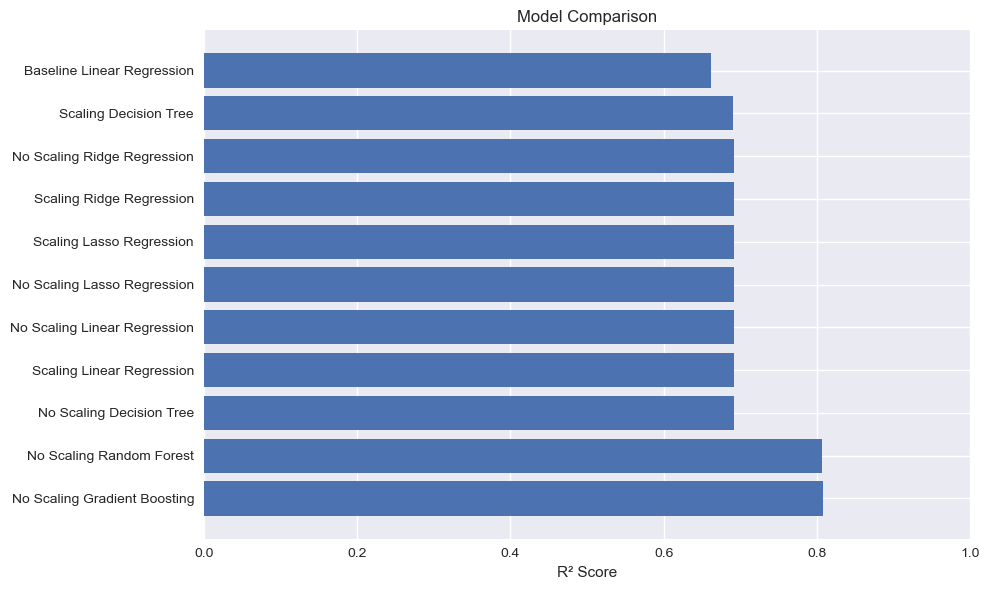

In [35]:
## TODO: create barplot of the R2 for all methods
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(result_df['Model'], result_df['R²'])

ax.set_xlabel('R² Score')
ax.set_title('Model Comparison')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Feature Refinement — Dropping Uninformative Features

More features ≠ better model. Extra features add noise and slow training.
We use two complementary methods to identify candidates for removal:

1. **Correlation with target** — a feature with |r| < 0.05 carries almost no signal
2. **Lasso coefficients** — features zeroed out by Lasso are redundant (given others)
3. **Inter-feature correlation** — if two features correlate > 0.85 with each other,
   keeping both is redundant (multicollinearity inflates variance in linear models)
4. **Feature importance** based on tree models

In [36]:
# Step 1: find features with absolute correlation < 0.05

correlation_matrix = pd.concat([X_train_standard,y_train],axis=1).corr()
correlations = correlation_matrix['median_house_value'].abs().sort_values(ascending=False)
correlations = correlations.drop('median_house_value')
correlations

MedInc                 0.691857
IncomeCategory         0.658672
RoomsPerPerson         0.412652
AveRooms               0.314524
AveOccup               0.279587
Region_North           0.252290
BedroomRatio           0.248038
Latitude               0.143751
Region_South           0.138835
DistToLA               0.129513
HouseAge               0.105821
AveBedrms              0.098091
AgeCategory_encoded    0.061077
Longitude              0.044926
Population             0.035938
DistToSF               0.028625
Name: median_house_value, dtype: float64

In [37]:
lasso.coef_

array([ 72702.179925  ,  15550.79258809,   1524.78298964,   -943.79435225,
         3630.86488646,  -2965.32397559, -47754.0585246 , -76987.5800149 ,
         3496.53355397,  38529.58403585,  36530.84097472,  -9980.40872674,
       -11820.87492477,  -2866.85174585, -19453.42666899,  64649.46839261])

In [38]:
# Step 2: Lasso zeroed-out features (from Lasso regression)
zeroed = X_train_standard.columns[lasso.coef_ == 0].tolist()
print("Features zeroed by Lasso:", zeroed if zeroed else "none at alpha=0.01")


Features zeroed by Lasso: none at alpha=0.01


In [39]:
# Step 3: find pairs with absolute correlation > 0.85
correlation_matrix_abs = correlation_matrix.abs()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range (i+1, len(correlation_matrix.columns)):
        if correlation_matrix_abs.iloc[i,j]>0.85:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j]))

In [40]:
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

print("Highly correlated feature pairs (>0.85):")
high_corr_df

Highly correlated feature pairs (>0.85):


,Feature 1,Feature 2,Correlation
0,Longitude,DistToSF,0.954635
1,MedInc,IncomeCategory,0.946511
2,Latitude,DistToLA,0.941632
3,DistToSF,Region_South,0.923799
4,Longitude,Region_South,0.890056
5,HouseAge,AgeCategory_encoded,0.870048
6,AveRooms,BedroomRatio,-0.885645
7,Longitude,DistToLA,-0.892450
8,Latitude,DistToSF,-0.898018
9,DistToLA,Region_South,-0.906162


In [41]:
high_corr_df.sort_values(by='Feature 1')

,Feature 1,Feature 2,Correlation
6,AveRooms,BedroomRatio,-0.885645
9,DistToLA,Region_South,-0.906162
3,DistToSF,Region_South,0.923799
5,HouseAge,AgeCategory_encoded,0.870048
2,Latitude,DistToLA,0.941632
8,Latitude,DistToSF,-0.898018
10,Latitude,Region_South,-0.923367
11,Latitude,Longitude,-0.924640
0,Longitude,DistToSF,0.954635
4,Longitude,Region_South,0.890056


In [42]:
## Step 4: feature importance 
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances

MedInc                 0.518687
HouseAge               0.037333
AveRooms               0.013068
AveBedrms              0.015987
Population             0.021565
AveOccup               0.120628
Latitude               0.055526
Longitude              0.044661
IncomeCategory         0.000511
RoomsPerPerson         0.028051
BedroomRatio           0.019734
DistToSF               0.070105
DistToLA               0.051909
AgeCategory_encoded    0.001159
Region_North           0.000799
Region_South           0.000278
dtype: float64

<Axes: >

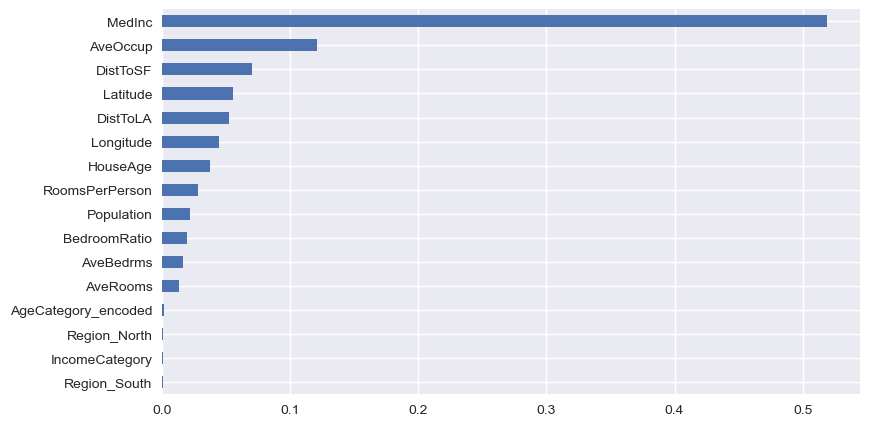

In [43]:
importances.sort_values(ascending=True).plot.barh(figsize=(9, 5))

###  Drop candidates

Based on the three diagnostics above, we will remove:

| Feature | Reason |
|---------|--------|
| `Population` | $|r|$ ≈ 0.04 — near-zero signal with target |
| `Region_North`, `Region_South` | Redundant: $|r|$ > 0.85 with `DisttoLA` and `Latitude`-based features |
| `IncomeCategory` | Redundant: $|r|$ > 0.85 with 'MedInc' |

We keep at most **one** of each highly correlated geographic pair.


In [44]:
# TODO: discussion features to drop
drop_cols = ['Region_North', 'Region_South','IncomeCategory','Population']



# Drop only the columns that actually exist in this dataset
drop_cols = [c for c in drop_cols if c in X_train.columns]
print(f"Dropping: {drop_cols}")

X_train_refined = X_train.drop(columns=drop_cols)
X_test_refined = X_test.drop(columns=drop_cols)

# For linear models, re-scale the refined set
from sklearn.preprocessing import StandardScaler
scaler_refined = StandardScaler()
X_train_refined_std = pd.DataFrame(
    scaler_refined.fit_transform(X_train_refined),columns=X_train_refined.columns)
X_test_refined_std  = pd.DataFrame(
    scaler_refined.transform(X_test_refined),columns=X_test_refined.columns)

print(f"Features: {X_train.shape[1]} → {X_train_refined.shape[1]}")


Dropping: ['Region_North', 'Region_South', 'IncomeCategory', 'Population']
Features: 16 → 12


###  Compare performance before vs after dropping

In [45]:
# TODO: Re-train key models on refined feature set
lr_ref = LinearRegression()
lr_ref.fit(X_train_refined_std,y_train)

## Random forest
rf_ref = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=4950, n_jobs=-1)
rf_ref.fit(X_train_refined, y_train)

## Gradient boost
gb_ref = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                               learning_rate=0.1, random_state=4950).fit(X_train_refined, y_train)

comparison = pd.DataFrame([
    {'Model': 'Linear Regression', 
     'Full features': result_df.loc[result_df['Model']=='Scaling Linear Regression','R²'].values[0],
     'Refined features': r2_score(y_test,lr_ref.predict(X_test_refined_std))} ,
    {'Model': 'Random Forest', 
     'Full features': result_df.loc[result_df['Model']=='No Scaling Random Forest','R²'].values[0],
     'Refined features': r2_score(y_test,rf_ref.predict(X_test_refined))} ,
    {'Model': 'Gradient Boosting', 
     'Full features': result_df.loc[result_df['Model']=='No Scaling Gradient Boosting','R²'].values[0],
     'Refined features': r2_score(y_test,gb_ref.predict(X_test_refined))} ,
])


comparison

,Model,Full features,Refined features
0,Linear Regression,0.692136,0.686771
1,Random Forest,0.806737,0.804237
2,Gradient Boosting,0.808483,0.807349


In [46]:
comparison['R² change'] = comparison['Refined features'] - comparison['Full features']
comparison

,Model,Full features,Refined features,R² change
0,Linear Regression,0.692136,0.686771,-0.005365
1,Random Forest,0.806737,0.804237,-0.002500
2,Gradient Boosting,0.808483,0.807349,-0.001135


## Introduce KFold

The Problem: Can We Trust One Split

Estimating how well the model generalizes to unseen data

In [47]:
from sklearn.model_selection import KFold, cross_val_score

In [48]:
cv = KFold(n_splits=5, shuffle=True, random_state=4950)

In [49]:
## TODO: linear regression with cross validation
lr_cv = LinearRegression()
scores_lr = cross_val_score(lr_cv, X_train_refined_std,y_train,
                           cv=cv,scoring='r2',n_jobs=-1)
print(f'Linear Regression    mean={scores_lr.mean():.4f}', f'std={scores_lr.std():.4f}',f'folds={np.round(scores_lr,3)}')


Linear Regression    mean=0.6891 std=0.0072 folds=[0.697 0.689 0.687 0.696 0.677]


In [50]:
print(f"Linear Regression       mean={scores_lr.mean():.4f}  "
      f"std={scores_lr.std():.4f}  folds={np.round(scores_lr,3)}")

Linear Regression       mean=0.6891  std=0.0072  folds=[0.697 0.689 0.687 0.696 0.677]


In [51]:
## TODO: linear regression with cross validation using make_pipeline
## (scaling handled internally to avoid data leakage)
from sklearn.pipeline import make_pipeline

lr_pipe = make_pipeline(StandardScaler(),LinearRegression())
scores = cross_val_score(lr_cv, X_train_refined,y_train,cv=cv,scoring='r2',n_jobs=-1)


cv_results = []
cv_results.append({'Model': 'Linear Regression', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print(f"Linear Regression      mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")

Linear Regression      mean=0.6891  std=0.0072  folds=[0.697 0.689 0.687 0.696 0.677]


In [52]:
# Ridge
ridge_cv = Ridge()
scores_rg = cross_val_score(ridge_cv, X_train_refined_std,y_train,
                           cv=cv,scoring='r2',n_jobs=-1)
print(f'Ridge Regression    mean={scores_rg.mean():.4f}', f'std={scores_rg.std():.4f}',f'folds={np.round(scores_rg,3)}')



Ridge Regression    mean=0.6891 std=0.0072 folds=[0.697 0.689 0.687 0.696 0.677]


In [53]:
# TODO: Ridge

ridge_pipe = make_pipeline(StandardScaler(),Ridge())
scores = cross_val_score(ridge_pipe, X_train_refined,y_train,cv=cv,scoring='r2',n_jobs=-1)

cv_results.append({'Model': 'Ridge Regression', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})


In [54]:
print(f"Ridge Regression      mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")

Ridge Regression      mean=0.6891  std=0.0072  folds=[0.697 0.689 0.687 0.696 0.677]


In [55]:
# Lasso
lasso_pipe = make_pipeline(StandardScaler(), Lasso(alpha=0.01))
scores = cross_val_score(lasso_pipe, X_train_refined, y_train, cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Lasso (α=0.01)', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print(f"Lasso (α=0.01)         mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")

Lasso (α=0.01)         mean=0.6891  std=0.0072  folds=[0.697 0.689 0.687 0.696 0.677]


In [56]:
# Random Forest
rf_cv = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=4950, n_jobs=-1)
scores = cross_val_score(rf_cv, X_train_refined, y_train, cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Random Forest', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print(f"Random Forest          mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")

Random Forest          mean=0.8106  std=0.0038  folds=[0.809 0.814 0.81  0.815 0.805]


In [57]:
# TODO: Gradient Boosting

gb_cv = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=4950)
scores = cross_val_score(gb_cv, X_train_refined, y_train, cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Gradient Boosting', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print(f"Gradient Boosting          mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")

Gradient Boosting          mean=0.8116  std=0.0054  folds=[0.808 0.812 0.813 0.821 0.805]


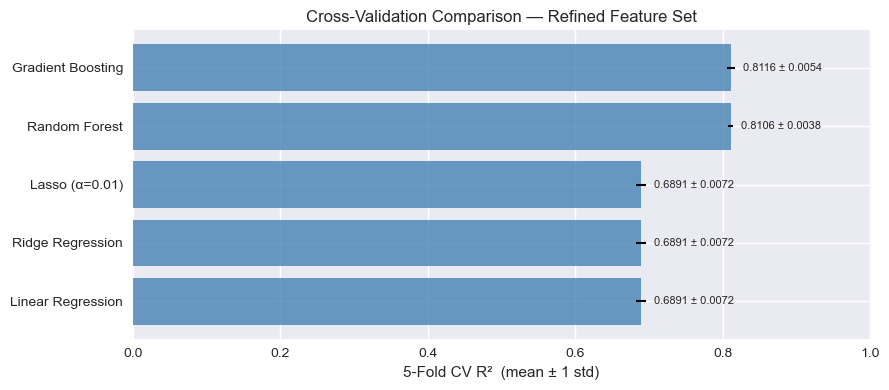

In [58]:
# Visualise CV mean ± 1 std
cv_df = pd.DataFrame(cv_results).sort_values('CV Mean R²', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_df['Model'], cv_df['CV Mean R²'],
        xerr=cv_df['CV Std'], color='steelblue', alpha=0.8,
        error_kw=dict(ecolor='black', capsize=5, lw=1.5))
ax.set_xlabel('5-Fold CV R²  (mean ± 1 std)')
ax.set_title('Cross-Validation Comparison — Refined Feature Set')
ax.set_xlim(0, 1.0)
for i, row in cv_df.iterrows():
    ax.text(row['CV Mean R²'] + row['CV Std'] + 0.01,
            list(cv_df.index).index(i),
            f"{row['CV Mean R²']:.4f} ± {row['CV Std']:.4f}",
            va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning with GridSearchCV

Searching for the optimal model configuration across parameter combinations

In [59]:
from sklearn.model_selection import GridSearchCV

### tuning: Ridge — tuning the regularization strength α

In [60]:
## TODO: define ridge_grid and perform the GridSearchCV

param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

ridge_grid = GridSearchCV(Ridge(),
                         param_grid = param_grid,
                         cv=cv,
                         scoring='r2', n_jobs= -1)

ridge_grid.fit(X_train_standard, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=4950, shuffle=True),
             estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='r2')

In [61]:
print(f'Best alpha: {ridge_grid.best_params_['alpha']}')
print(f'CV R2 with best alpha: {ridge_grid.best_score_:.6f}')

Best alpha: 1
CV R2 with best alpha: 0.695758


In [62]:
# Show how R² changes across alpha values
ridge_cv_df = pd.DataFrame(ridge_grid.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
ridge_cv_df.columns = ['alpha', 'mean_R²', 'std_R²']
print()
print(ridge_cv_df.round(6).to_string(index=False))


 alpha  mean_R²   std_R²
 0.001 0.695758 0.007350
  0.01 0.695758 0.007350
   0.1 0.695758 0.007350
     1 0.695758 0.007349
    10 0.695751 0.007337
   100 0.694816 0.007236
  1000 0.673153 0.006396


In [63]:
## TODO: predict on test data

y_pred = ridge_grid.best_estimator_.predict(X_test_standard)

In [64]:
print('=== Ridge Regression (Tuned) ===')
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results.append({'Model': 'Ridge Regression (tuned)', 'R²': r2, 'RMSE': rmse})
print(f'Ridge Regression: R² = {r2:.6f}, RMSE = {rmse:.6f}')

=== Ridge Regression (Tuned) ===
Ridge Regression: R² = 0.692130, RMSE = 63595.911627


In [65]:
## Use make_pipeline to perform the GridSearchCV

ridge_pipe = make_pipeline(StandardScaler(), Ridge())
ridge_grid2 = GridSearchCV(ridge_pipe,
                         param_grid={'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
                         cv=cv,
                         scoring='r2', n_jobs= -1)

ridge_grid2.fit(X_train, y_train)

print(f'Best alpha: {ridge_grid2.best_params_['ridge__alpha']}')
print(f'CV R2 with best alpha: {ridge_grid2.best_score_:.6f}')

Best alpha: 1
CV R2 with best alpha: 0.695758


In [66]:
# Show how R² changes across alpha values
ridge_cv_df2 = pd.DataFrame(ridge_grid2.cv_results_)[['param_ridge__alpha', 'mean_test_score', 'std_test_score']]
ridge_cv_df2.columns = ['alpha', 'mean_R²', 'std_R²']
print()
print(ridge_cv_df2.round(6).to_string(index=False))


 alpha  mean_R²   std_R²
 0.001 0.695758 0.007350
  0.01 0.695758 0.007350
   0.1 0.695758 0.007350
     1 0.695758 0.007350
    10 0.695755 0.007346
   100 0.695065 0.007313
  1000 0.677638 0.006751


### tuning: Random Forest — depth and feature sampling

In [67]:
## TODO: define rf_grid

param_grid={
        'n_estimators': [100, 200],
        'max_depth':    [8, 12, 15, None],
        'max_features': ['sqrt', 0.5],
    }

rf_grid = GridSearchCV(RandomForestRegressor(random_state=4950, n_jobs=-1),
                      param_grid= param_grid,
                      cv=cv, scoring='r2', n_jobs=-1)

rf_grid.fit(X_train, y_train)

print(f"Best params: {rf_grid.best_params_}")
print(f"CV R²:       {rf_grid.best_score_:.4f}")
print()

# Top 5 combinations
rf_cv_df = (pd.DataFrame(rf_grid.cv_results_)
            [['param_max_depth', 'param_max_features', 'mean_test_score', 'std_test_score']]
            .sort_values('mean_test_score', ascending=False)
            .head(5))
rf_cv_df.columns = ['max_depth', 'max_features', 'mean_R²', 'std_R²']
print("Top 5 combinations:")
print(rf_cv_df.round(4).to_string(index=False))


Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
CV R²:       0.8225

Top 5 combinations:
max_depth max_features  mean_R²  std_R²
     None         sqrt   0.8225  0.0034
     None         sqrt   0.8205  0.0040
       15         sqrt   0.8187  0.0033
     None          0.5   0.8184  0.0035
       15         sqrt   0.8179  0.0038


In [68]:
print(rf_cv_df.round(6).to_string(index=False))

max_depth max_features  mean_R²   std_R²
     None         sqrt 0.822512 0.003386
     None         sqrt 0.820516 0.004021
       15         sqrt 0.818672 0.003263
     None          0.5 0.818377 0.003528
       15         sqrt 0.817887 0.003751


In [69]:
y_pred = rf_grid.best_estimator_.predict(X_test)


print('=== Random Forest (Tuned) ===')
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results.append({'Model': 'Random Forest (tuned)', 'R²': r2, 'RMSE': rmse})
print(f'Random Forest: R² = {r2:.4f}, RMSE = {rmse:.4f}')

=== Random Forest (Tuned) ===
Random Forest: R² = 0.8260, RMSE = 47813.6543


### tuning: Gradient Boosting — learning rate and depth

In [70]:
## TODO: define gb_grid

param_grid={
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 4, 5],
    }

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=4950),
                      param_grid=param_grid,
                       cv=cv, scoring='r2', n_jobs=-1)


gb_grid.fit(X_train, y_train)

print(f"Best params: {gb_grid.best_params_}")
print(f"CV R²:       {gb_grid.best_score_:.4f}")
print()

gb_cv_df = (pd.DataFrame(gb_grid.cv_results_)
            [['param_n_estimators', 'param_learning_rate', 'param_max_depth',
              'mean_test_score', 'std_test_score']]
            .sort_values('mean_test_score', ascending=False)
            .head(5))
gb_cv_df.columns = ['n_est', 'lr', 'max_depth', 'mean_R²', 'std_R²']
print("Top 5 combinations:")
print(gb_cv_df.round(4).to_string(index=False))

Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
CV R²:       0.8372

Top 5 combinations:
n_est   lr max_depth  mean_R²  std_R²
  200  0.2         5   0.8372  0.0032
  200  0.1         5   0.8348  0.0035
  200  0.2         4   0.8344  0.0038
  100  0.2         5   0.8319  0.0047
  200  0.1         4   0.8288  0.0028


In [71]:
y_pred = gb_grid.best_estimator_.predict(X_test)


print('=== Gradient Boosting (Tuned) ===')
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results.append({'Model': 'Gradient Boosting (tuned)', 'R²': r2, 'RMSE': rmse})
print(f'Gradient Boosting: R² = {r2:.4f}, RMSE = {rmse:.4f}')

=== Gradient Boosting (Tuned) ===
Gradient Boosting: R² = 0.8398, RMSE = 45875.9104


### tuning summary: default vs tuned

In [72]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False)

print('Model Comparison')
print('=' * 50)
print(results_df.to_string(index=False))

Model Comparison
                       Model       R²         RMSE
   Gradient Boosting (tuned) 0.839794 45875.910407
       Random Forest (tuned) 0.825975 47813.654332
No Scaling Gradient Boosting 0.808483 50158.995624
    No Scaling Random Forest 0.806737 50387.200254
    No Scaling Decision Tree 0.692216 63587.073558
   Scaling Linear Regression 0.692136 63595.339627
No Scaling Linear Regression 0.692136 63595.339627
 No Scaling Lasso Regression 0.692136 63595.340263
    Scaling Lasso Regression 0.692136 63595.341281
    Ridge Regression (tuned) 0.692130 63595.911627
    Scaling Ridge Regression 0.692072 63601.902064
 No Scaling Ridge Regression 0.691822 63627.724001
       Scaling Decision Tree 0.690039 63811.468874
  Baseline Linear Regression 0.661643 66670.424121


In [75]:
## TODO: default vs tuned


comparison_tune_scaling = pd.DataFrame([
    {'Model': 'Ridge Regression', 
     'Default': results_df.loc[results_df['Model']=='Scaling Ridge Regression', 'R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Ridge Regression (tuned)', 'R²'].values[0]},
    {'Model': 'Random Forest',
    'Default': results_df.loc[results_df['Model']=='No Scaling Random Forest', 'R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Random Forest (tuned)', 'R²'].values[0]},
    {'Model': 'Gradient Boosting',
    'Default': results_df.loc[results_df['Model']=='No Scaling Gradient Boosting', 'R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Gradient Boosting (tuned)', 'R²'].values[0]},
])
comparison_tune_scaling['Δ R²'] = (comparison_tune_scaling['Tuned'] - comparison_tune_scaling['Default']).round(4)
comparison_tune_scaling[['Default', 'Tuned']] = comparison_tune_scaling[['Default', 'Tuned']].round(4)
print(comparison_tune_scaling.to_string(index=False))

            Model  Default  Tuned   Δ R²
 Ridge Regression   0.6921 0.6921 0.0001
    Random Forest   0.8067 0.8260 0.0192
Gradient Boosting   0.8085 0.8398 0.0313


In [76]:
# Only need to compute CV scores — test scores already in results_df
ridge_cv = cross_val_score(ridge_grid.best_estimator_, X_train_standard, y_train, cv=cv, scoring='r2', n_jobs=-1)
rf_cv    = cross_val_score(rf_grid.best_estimator_,    X_train,     y_train, cv=cv, scoring='r2', n_jobs=-1)
gb_cv    = cross_val_score(gb_grid.best_estimator_,    X_train,     y_train, cv=cv, scoring='r2', n_jobs=-1)

# Pull test scores directly from results_df
ridge_row = results_df[results_df['Model'] == 'Ridge Regression (tuned)'].iloc[0]
rf_row    = results_df[results_df['Model'] == 'Random Forest (tuned)'].iloc[0]
gb_row    = results_df[results_df['Model'] == 'Gradient Boosting (tuned)'].iloc[0]

final_df = pd.DataFrame({
    'Model':      ['Ridge (tuned)', 'Random Forest (tuned)', 'Gradient Boosting (tuned)'],
    'CV R2 mean': [ridge_cv.mean(), rf_cv.mean(), gb_cv.mean()],
    'CV R2 std':  [ridge_cv.std(),  rf_cv.std(),  gb_cv.std()],
    'Test R2':    [ridge_row['R²'], rf_row['R²'], gb_row['R²']],
    'Test RMSE':  [ridge_row['RMSE'], rf_row['RMSE'], gb_row['RMSE']],
}).round(4).sort_values('Test R2', ascending=False)

print(final_df.to_string(index=False))

                    Model  CV R2 mean  CV R2 std  Test R2  Test RMSE
Gradient Boosting (tuned)      0.8372     0.0032   0.8398 45875.9104
    Random Forest (tuned)      0.8225     0.0034   0.8260 47813.6543
            Ridge (tuned)      0.6958     0.0073   0.6921 63595.9116


## Model Selection

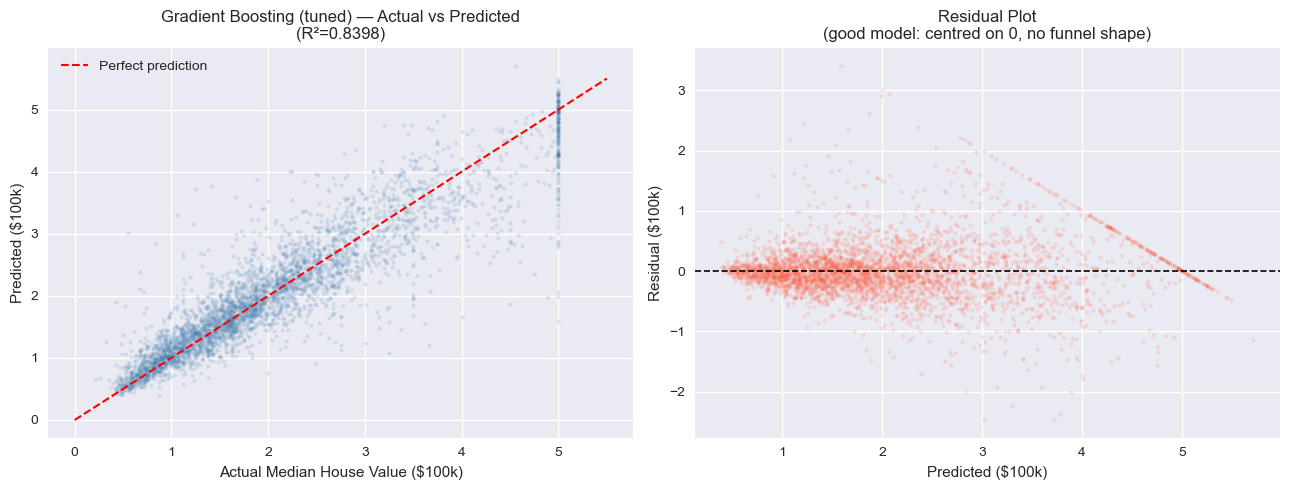

In [77]:
best_model  = gb_grid.best_estimator_   # swap to rf_grid if RF wins
best_name   =  'Gradient Boosting (tuned)'
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test / 1e5, y_pred_best / 1e5, alpha=0.15, s=6, color='steelblue')
lims = [0, 5.5]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Median House Value ($100k)')
axes[0].set_ylabel('Predicted ($100k)')
axes[0].set_title(f'{best_name} — Actual vs Predicted\n(R²={r2_score(y_test, y_pred_best):.4f})')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best / 1e5, residuals / 1e5, alpha=0.15, s=6, color='tomato')
axes[1].axhline(0, color='black', lw=1.2, linestyle='--')
axes[1].set_xlabel('Predicted ($100k)')
axes[1].set_ylabel('Residual ($100k)')
axes[1].set_title('Residual Plot\n(good model: centred on 0, no funnel shape)')

plt.tight_layout()
plt.show()

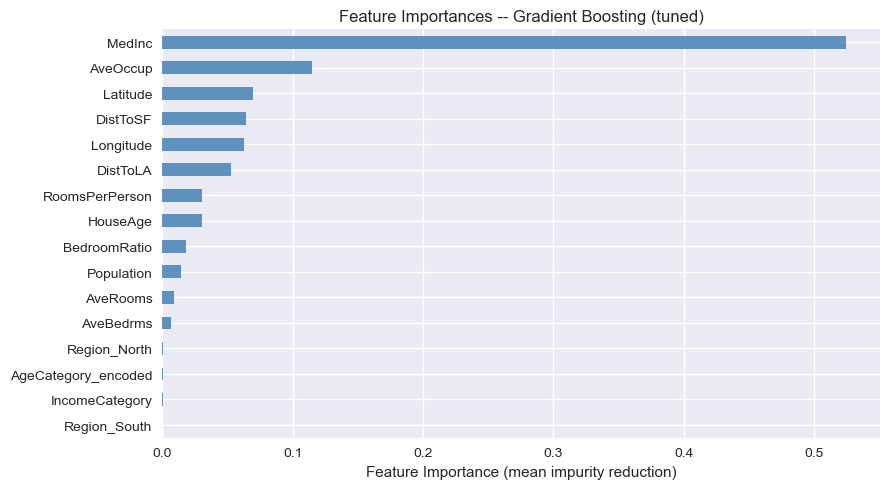

Top 5 most important features:
MedInc       0.5243
AveOccup     0.1149
Latitude     0.0696
DistToSF     0.0642
Longitude    0.0628


In [79]:
# Feature importance — best tree model
importances = pd.Series(best_model.feature_importances_,
                        index=X_train.columns)   # <- refined columns, not full X_train
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
importances_sorted.plot.barh(ax=ax, color='steelblue', alpha=0.85)
ax.set_xlabel('Feature Importance (mean impurity reduction)')
ax.set_title(f'Feature Importances -- {best_name}')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importances.sort_values(ascending=False).head(5).round(4).to_string())


## Save Best Model

In [ ]:
## save best model

import pickle, os
os.makedirs('../models', exist_ok=True)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved:  ../models/best_model.pkl')
print(f"Model : {type(best_model).__name__}")
print(f"Params: {gb_grid.best_params_}")
print(f"Test R2: {r2_score(y_test, y_pred_best):.4f}")
print(f"Test RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_best)):,.0f}")
